数据集已保存为 'same_normal_anomaly.csv'，共50个异常点


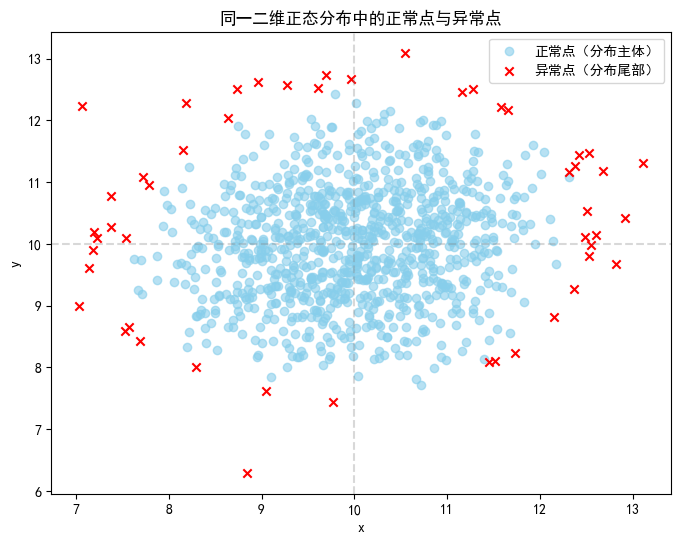

In [15]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis
import matplotlib.pyplot as plt

# --------------------------
# 1. 定义单个二维正态分布参数
# --------------------------
mean = [10, 10]  # 均值向量（分布中心）
cov = [[1, 0.1],  # 协方差矩阵（控制分布形状：对角线为方差，非对角线为相关性）
       [0.1, 1]]
n_samples = 1000  # 总样本数（全部来自该分布）


# --------------------------
# 2. 从该分布生成所有样本
# --------------------------
all_points = np.random.multivariate_normal(mean=mean, cov=cov, size=n_samples)


# --------------------------
# 3. 计算马氏距离，标记异常点
# --------------------------
# 马氏距离公式：D = sqrt( (x-μ)^T Σ^(-1) (x-μ) )，其中Σ是协方差矩阵
cov_inv = np.linalg.inv(cov)  # 协方差矩阵的逆

# 计算每个点到均值的马氏距离
mahalanobis_distances = []
for point in all_points:
    dist = mahalanobis(point, mean, cov_inv)
    mahalanobis_distances.append(dist)

# 设定阈值：取距离的95%分位数（即95%的点距离小于该值，剩余5%为异常）
threshold = np.percentile(mahalanobis_distances, 95)

# 标记标签：距离 > 阈值 → 异常（1），否则正常（0）
labels = np.where(np.array(mahalanobis_distances) > threshold, 1, 0)


# --------------------------
# 4. 保存为CSV文件
# --------------------------
df = pd.DataFrame({
    'x': all_points[:, 0],  # 第一维特征
    'y': all_points[:, 1],  # 第二维特征
    'label': labels  # 0=正常，1=异常
})
df.to_csv('异常检测数据集.csv', index=False)
print(f"数据集已保存为 'same_normal_anomaly.csv'，共{sum(labels)}个异常点")


# --------------------------
# 5. 可视化验证（所有点来自同一分布）
# --------------------------
plt.figure(figsize=(8, 6))
# 正常点（蓝色）
plt.scatter(
    df[df['label']==0]['x'], 
    df[df['label']==0]['y'], 
    c='skyblue', alpha=0.6, label='正常点（分布主体）'
)
# 异常点（红色，分布尾部）
plt.scatter(
    df[df['label']==1]['x'], 
    df[df['label']==1]['y'], 
    c='red', marker='x', label='异常点（分布尾部）'
)
plt.axhline(y=mean[1], color='gray', linestyle='--', alpha=0.3)  # 中心水平线
plt.axvline(x=mean[0], color='gray', linestyle='--', alpha=0.3)  # 中心垂直线
plt.xlabel('x')
plt.ylabel('y')
plt.title('同一二维正态分布中的正常点与异常点')
plt.legend()
plt.show()